# Backends and Algorithms

Quantum Launcher provides convenient wrappers for the most popular quantum computing backends, as well as a set of common quantum algorithms.

In [1]:
import networkx as nx

from quantum_launcher.routines.qiskit_routines import QAOA, QiskitBackend
from quantum_launcher.routines.dwave_routines import SimulatedAnnealingBackend, DwaveSolver
from quantum_launcher.routines.orca_routines import OrcaBackend, BBS
from quantum_launcher.launcher import QuantumLauncher
from quantum_launcher.problems import MaxCut

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Problem definition
Let's define a simple max cut problem instance using NetworkX

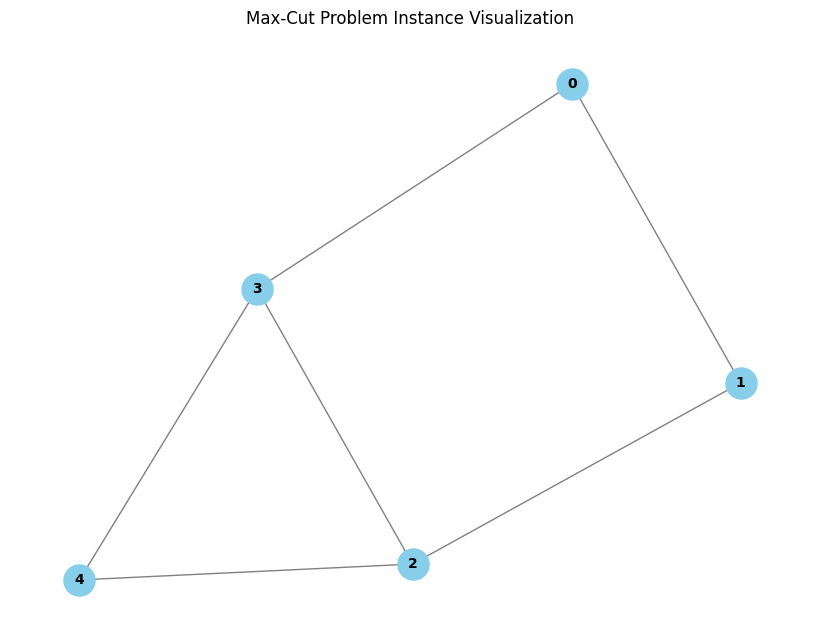

In [2]:
node_list = list(range(5))
edge_list = [(0, 1), (1, 2), (2, 3), (3, 0), (3, 4), (2, 4)]

graph = nx.Graph()
graph.add_nodes_from(node_list)
graph.add_edges_from(edge_list)

problem = MaxCut(graph, instance_name="my problem")


problem.visualize()

## Solutions
We only need to define the problem once. To solve the same problem on a different backend, only the backend instance and a backend-specific algorithm need to be provided. 

### Qiskit and QAOA

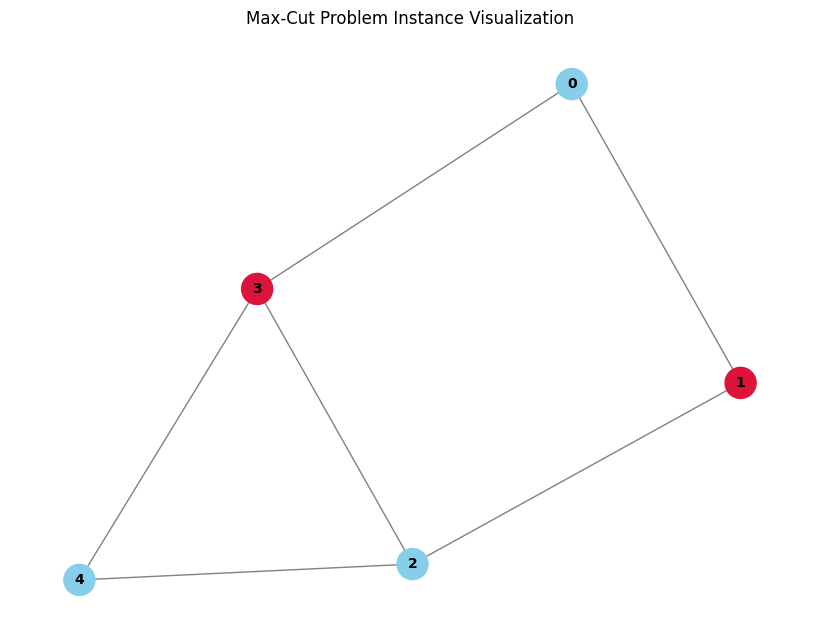

In [3]:
alg = QAOA()
backend = QiskitBackend('local_simulator')

launcher = QuantumLauncher(problem, alg, backend)
result = launcher.run()
problem.visualize(result.best_bitstring[::-1])

### D-Wave backend and solver

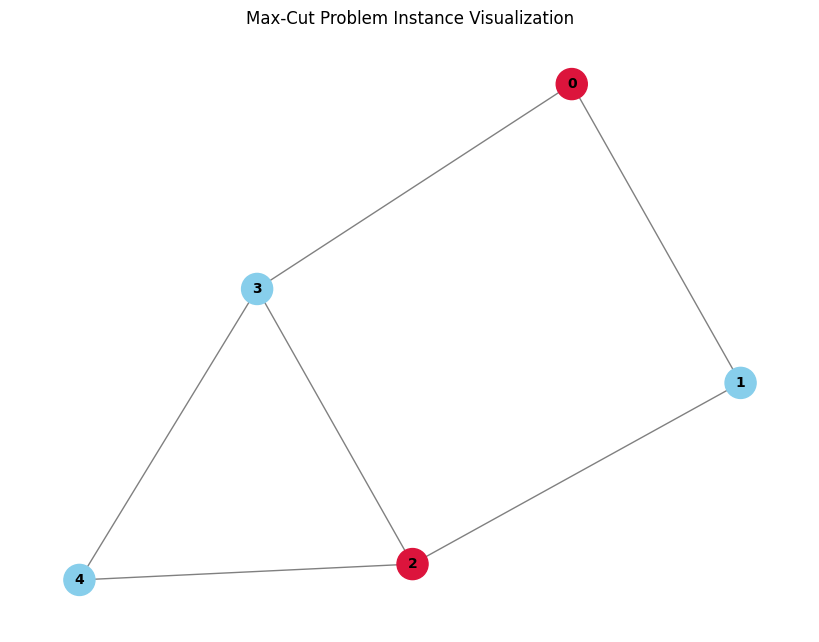

In [4]:
alg = DwaveSolver(1)
backend = SimulatedAnnealingBackend('local')
launcher = QuantumLauncher(problem, alg, backend)
result = launcher.run()
problem.visualize(result.best_bitstring)

## 

### Orca backend and solver

Training loop 1: loss is -2.99
Training loop 50: loss is -4.61
Training loop 100: loss is -4.65


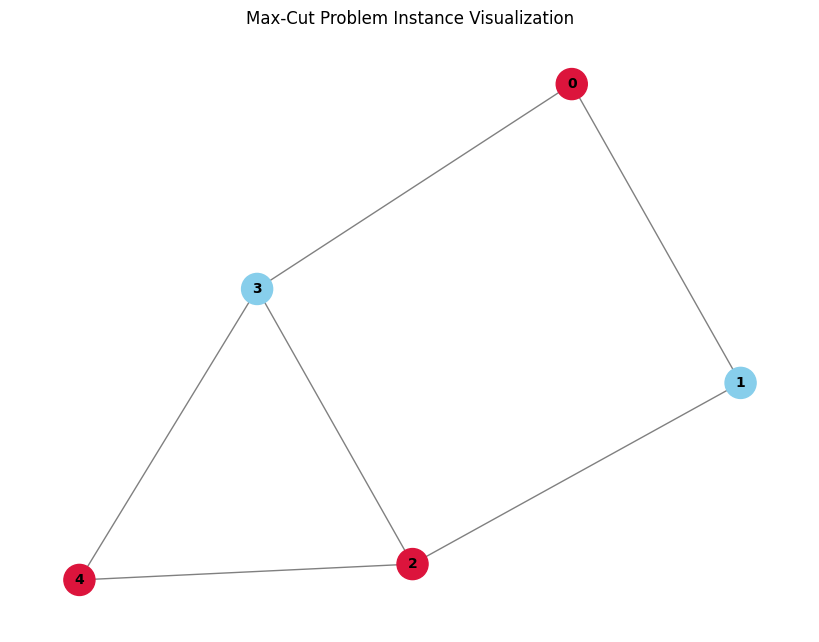

In [5]:
alg = BBS()
backend = OrcaBackend('local')
launcher = QuantumLauncher(problem, alg, backend)
result = launcher.run()

problem.visualize(result.best_bitstring)